<a href="https://colab.research.google.com/github/Samiksha28-k/Bat-Ball-Stamp-Game/blob/main/cliff_walking_salsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium

In [ ]:
!pip install "gymnasium[toy-text]"

In [ ]:
import gymnasium as gym
import numpy as np
import random

In [ ]:
#sample env
env = gym.make("CliffWalking-v1")

In [ ]:
print(env.observation_space.n)
print(env.action_space.n)

staring_state, _ = env.reset()
print(staring_state)

48
4
36


In [ ]:
#SARSA

gamma = 0.99
alpha = 0.5
epsilon = 0.1
episodes = 500

In [ ]:
# Q-table => store  Q-values
Q = np.zeros((48,4))

In [ ]:
#policy - epsilon_greedy : state -> action

def epsilon_greedy(state):
  if random.random() < epsilon:
    return env.action_space.sample() # random action => Explore
  else:
    return np.argmax(Q[state]) # exploit

In [ ]:
for episode in range(episodes):

  env= gym.make("CliffWalking-v1")
  done = False # when the episode has ended
  state, _ = env.reset()
  action = epsilon_greedy(state)

  total_reward = 0
  episode_len = 0
  while not done:
    next_state, reward,terminated,truncated,_ = env.step(action)
    done  = terminated or truncated
    next_action = epsilon_greedy(next_state)

    # Sarsa Update
    Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])
    state = next_state
    action = next_action
    total_reward += reward
    episode_len += 1
  print(f"episode = {episode+1}/500 : tot reward = {total_reward}  & ep length = {episode_len}")
  env.close()

episode = 1/500 : tot reward = -669  & ep length = 174
episode = 2/500 : tot reward = -1461  & ep length = 471
episode = 3/500 : tot reward = -98  & ep length = 98
episode = 4/500 : tot reward = -173  & ep length = 74
episode = 5/500 : tot reward = -87  & ep length = 87
episode = 6/500 : tot reward = -26  & ep length = 26
episode = 7/500 : tot reward = -129  & ep length = 129
episode = 8/500 : tot reward = -179  & ep length = 80
episode = 9/500 : tot reward = -24  & ep length = 24
episode = 10/500 : tot reward = -35  & ep length = 35
episode = 11/500 : tot reward = -109  & ep length = 109
episode = 12/500 : tot reward = -48  & ep length = 48
episode = 13/500 : tot reward = -46  & ep length = 46
episode = 14/500 : tot reward = -53  & ep length = 53
episode = 15/500 : tot reward = -64  & ep length = 64
episode = 16/500 : tot reward = -29  & ep length = 29
episode = 17/500 : tot reward = -129  & ep length = 30
episode = 18/500 : tot reward = -78  & ep length = 78
episode = 19/500 : tot re

In [ ]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import time

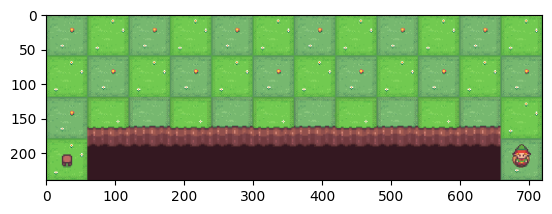

tot reward = -17  & ep length = 17


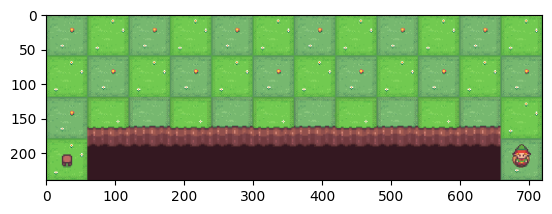

In [ ]:
env = gym.make("CliffWalking-v1",render_mode="rgb_array")
done = False
state, _ = env.reset()
total_reward = 0
episode_len = 0

while not done:
  action = np.argmax(Q[state])
  next_state,reward,terminated,truncated, _ = env.step(action)
  done = terminated or truncated
  state = next_state
  frame = env.render()
  clear_output(wait=True)
  plt.imshow(frame)
  display(plt.gcf())
  time.sleep(0.3)

  total_reward += reward
  episode_len += 1
print(f"tot reward = {total_reward}  & ep length = {episode_len}")
env.close()